<a href="https://colab.research.google.com/github/DavidBond228/LAB1-Linear-/blob/main/LAB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X = np.array([[0, 0, 0, 2, 0, 2],
              [0, 4, 2, 4, 2, 0]])

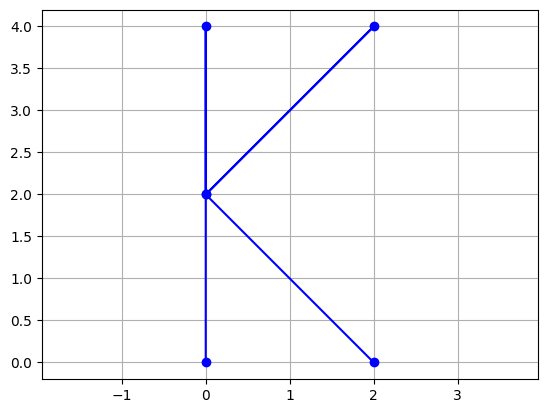

In [3]:
plt.plot(X[0], X[1], 'b-o')
plt.axis('equal')
plt.grid(True)
plt.show()

In [4]:
S = np.array([[2,0],[0,1]])

In [5]:
X_new = S @ X

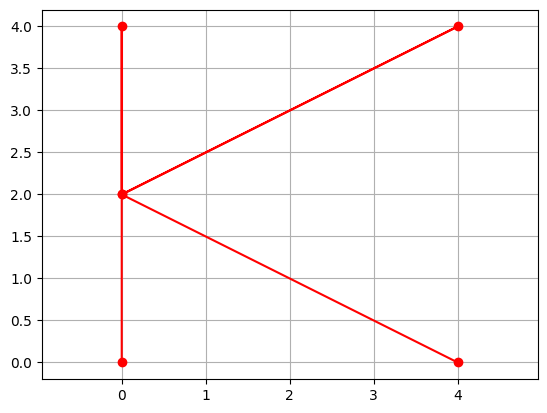

In [6]:
plt.plot(X_new[0], X_new[1], 'r-o')
plt.axis('equal')
plt.grid(True)
plt.show()

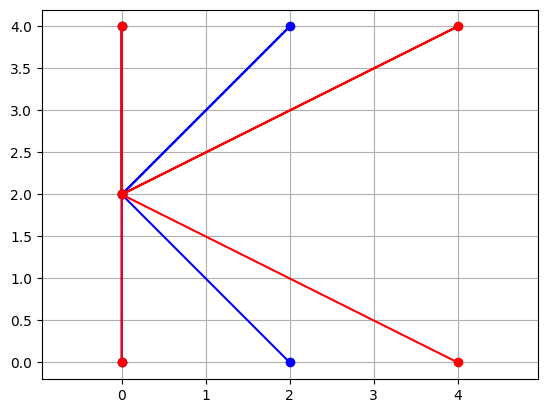

In [7]:
plt.plot(X[0],X[1] , 'b-o')
plt.plot(X_new[0], X_new[1] , 'r-o')
plt.axis('equal')
plt.grid(True)
plt.show()

In [8]:
def stretch(X, a, b):
    S = np.array([[a, 0], [0, b]])
    return S @ X

Матриця stretch:
[[2 0]
 [0 1]]


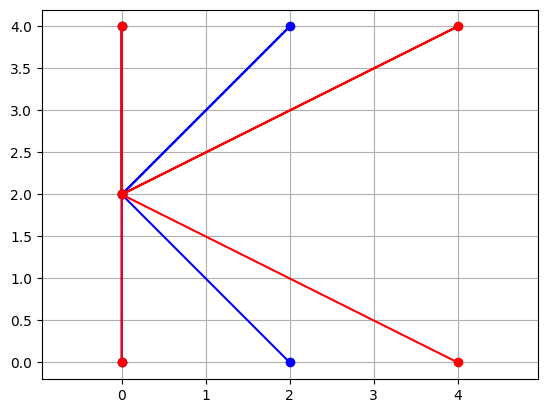

In [35]:
S = np.array([[2, 0], [0, 1]])
print("Матриця stretch:")
print(S)
show(X, stretch(X, 2, 1))

In [11]:
def shear(X, a, b):
    S = np.array([[1, a], [b, 1]])
    return S @ X

Матриця shear:
[[1.  0.5]
 [0.  1. ]]


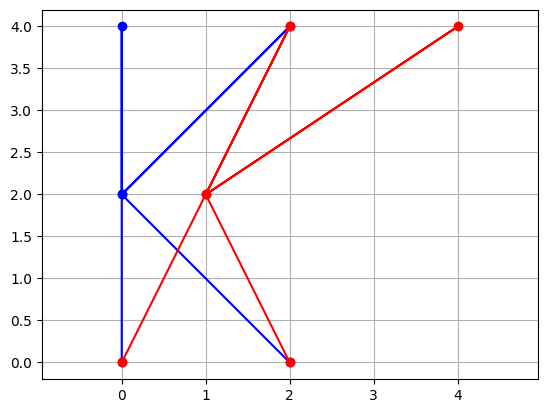

In [34]:
S = np.array([[1, 0.5], [0, 1]])
print("Матриця shear:")
print(S)
show(X, shear(X, 0.5, 0))

In [13]:
def reflection(X, a, b):
    S = (1 / (a**2 + b**2)) * np.array([[a**2 - b**2, 2*a*b], [2*a*b, b**2 - a**2]])
    return S @ X

In [14]:
def rotation(X, theta):
    S = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta), np.cos(theta)]])
    return S @ X

In [15]:
def show(orig, transf):
    plt.plot(orig[0], orig[1], 'b-o')
    plt.plot(transf[0], transf[1], 'r-o')
    plt.axis('equal')
    plt.grid(True)
    plt.show()

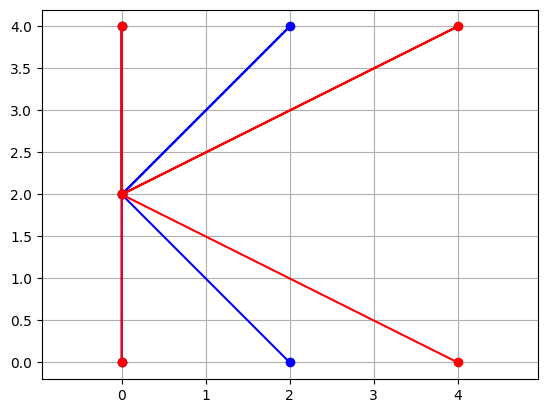

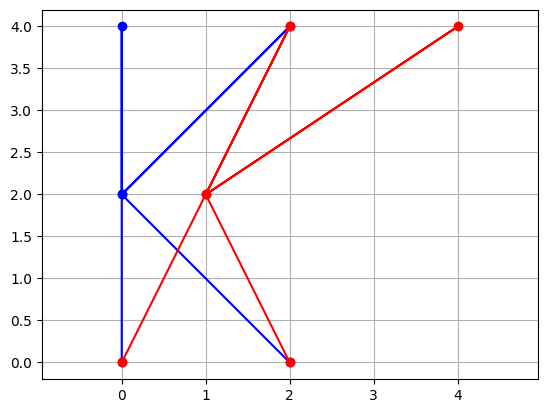

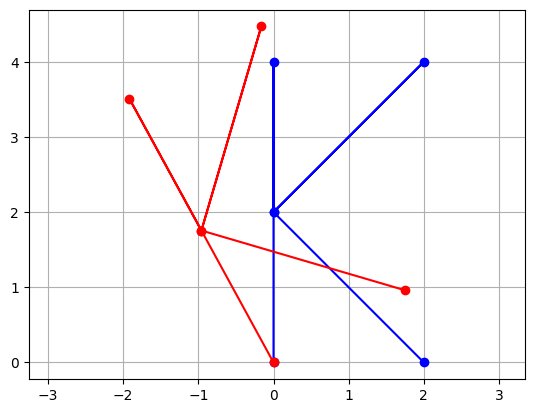

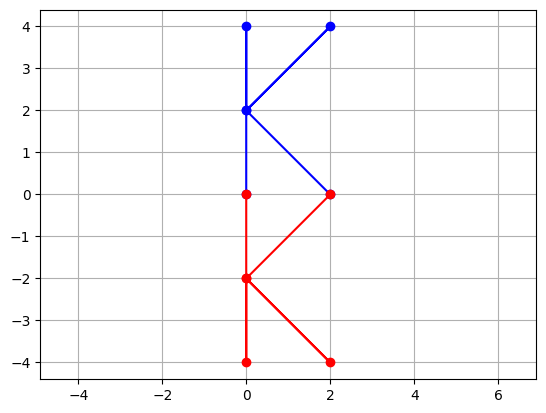

In [16]:
show(X, stretch(X, 2, 1))
show(X, shear(X, 0.5, 0))
show(X, rotation(X, 0.5))
show(X, reflection(X, 1, 0))

In [17]:
print("stretch:")
print(np.array([[2, 0], [0, 1]]))
print("shear:")
print(np.array([[1, 0.5], [0, 1]]))
print("rotation:")
print(np.array([[np.cos(0.5), -np.sin(0.5)], [np.sin(0.5), np.cos(0.5)]]))
print("reflection:")
print(np.array([[1, 0], [0, -1]]))

stretch:
[[2 0]
 [0 1]]
shear:
[[1.  0.5]
 [0.  1. ]]
rotation:
[[ 0.87758256 -0.47942554]
 [ 0.47942554  0.87758256]]
reflection:
[[ 1  0]
 [ 0 -1]]


In [25]:
rotation( shear(X, 0.5, 0),  0.5)

array([[ 0.        , -0.16253703, -0.08126852,  1.59262809, -0.08126852,
         1.75516512],
       [ 0.        ,  4.46918132,  2.23459066,  5.4280324 ,  2.23459066,
         0.95885108]])

In [24]:
shear(rotation(X, 0.5), 0.5, 0)

array([[ 0.        , -0.16253703, -0.08126852,  2.07205363, -0.08126852,
         2.23459066],
       [ 0.        ,  3.51033025,  1.75516512,  4.46918132,  1.75516512,
         0.95885108]])

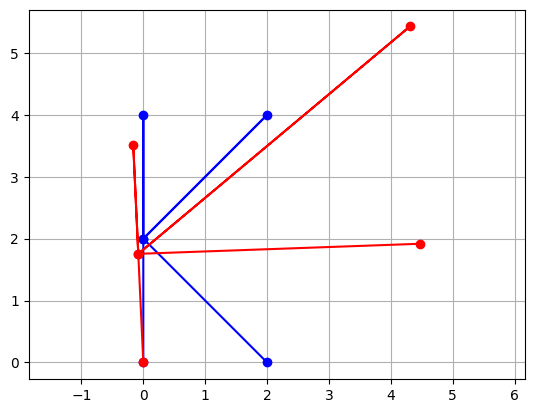

In [23]:
show(X, shear(rotation(stretch(X, 2, 1), 0.5), 0.5, 0))

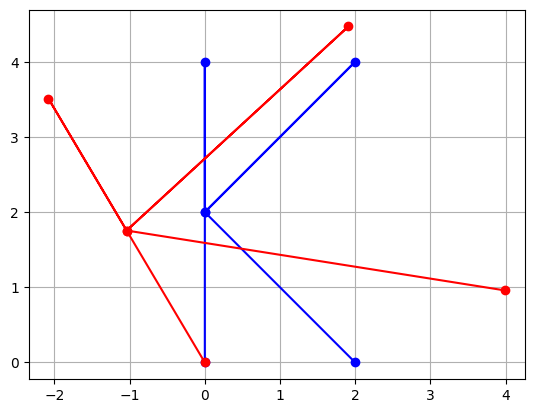

In [22]:
b1 = rotation(X, 0.5)
b2 = stretch(b1, 2, 1)
b3 = shear(b2, 0.5, 0)
show(X, b3)

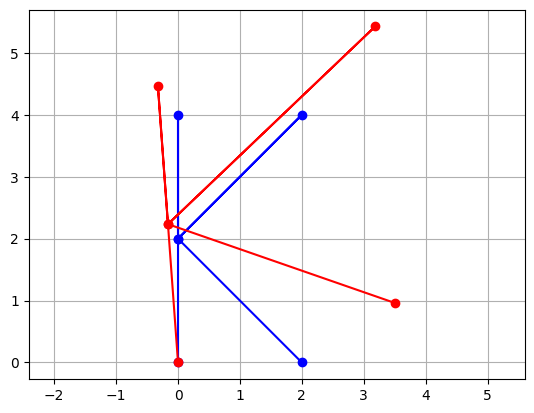

In [21]:
c1 = shear(X, 0.5, 0)
c2 = rotation(c1, 0.5)
c3 = stretch(c2, 2, 1)
show(X, c3)

Результат залежить від порядку трансформацій. Ті самі stretch, shear, rotation у різній послідовності дають різні фігури - множення матриць некомутативне.

In [20]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"davidtepanian","key":"3813427bb0d8c577ae3fe933440b9a16"}'}

In [19]:
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
!cp kaggle.json /root/.config/kaggle/
!chmod 600 /root/.config/kaggle/kaggle.json
!pip install kaggle -q

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.config/kaggle/kaggle.json': No such file or directory


In [36]:
!kaggle datasets download -d balraj98/modelnet40-princeton-3d-object-dataset -f ModelNet40/airplane/train/airplane_0001.off
!unzip -o airplane_0001.off.zip

Dataset URL: https://www.kaggle.com/datasets/balraj98/modelnet40-princeton-3d-object-dataset
License(s): other
airplane_0001.off.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  airplane_0001.off.zip
  inflating: airplane_0001.off       


In [26]:
def read_off(filename):
    with open(filename, 'r') as f:
        if 'OFF' != f.readline().strip():
            raise ValueError('Not a valid OFF header')
        n_verts, n_faces, _ = map(int, f.readline().strip().split())
        verts = [list(map(float, f.readline().strip().split())) for _ in range(n_verts)]
        faces = [list(map(int, f.readline().strip().split()[1:])) for _ in range(n_faces)]
    return np.array(verts), faces

vertices, faces = read_off("airplane_0001.off")
print("Форма вершин:",vertices.shape)

Форма вершин: (90714, 3)


In [30]:
X3 = vertices.T
print("Nova форма:", X3.shape)

Nova форма: (3, 90714)


In [29]:
def rotate_xy(X, theta):
    S = np.array([[np.cos(theta), -np.sin(theta), 0],
                  [np.sin(theta),  np.cos(theta), 0],
                  [0,              0,             1]])
    return S @ X

In [28]:
def rotate_yz(X, theta):
    S = np.array([[1, 0,             0],
                  [0, np.cos(theta), -np.sin(theta)],
                  [0, np.sin(theta),  np.cos(theta)]])
    return S @ X

In [27]:
def rotate_xz(X, theta):
    S = np.array([[np.cos(theta), 0, -np.sin(theta)],
                  [0,             1,  0],
                  [np.sin(theta), 0,  np.cos(theta)]])
    return S @ X

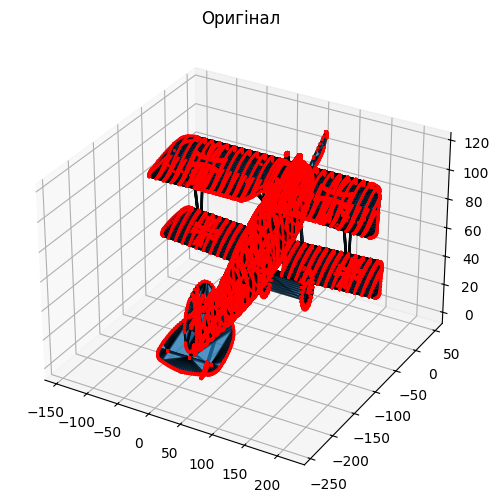

In [31]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_off(vertices, faces, title=""):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    mesh = Poly3DCollection([vertices[face] for face in faces], alpha=0.3, edgecolor='k')
    ax.add_collection3d(mesh)
    ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], s=1, c='r')
    ax.set_title(title)
    ax.auto_scale_xyz(vertices[:, 0], vertices[:, 1], vertices[:, 2])
    plt.show()

plot_off(vertices, faces, "Оригінал")

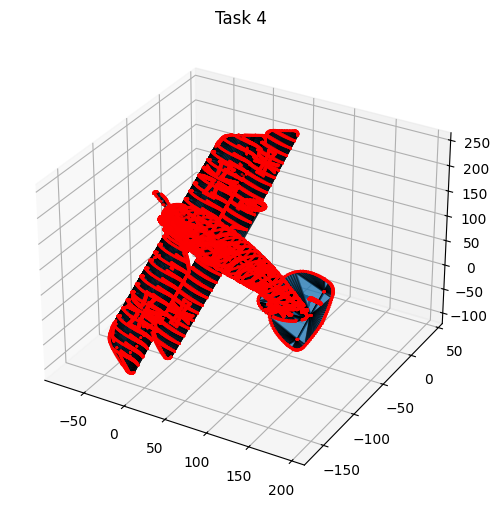

In [32]:
r1 = rotate_xy(X3, 0.7)
r2 = rotate_yz(r1, 0.8)
r3 = rotate_xz(r2, 0.9)
plot_off(r3.T, faces, "Task 4")

In [33]:
theta = 0.7
print("rotate_xy:")
print(np.array([[np.cos(theta), -np.sin(theta), 0],[np.sin(theta), np.cos(theta), 0],[0,0,1]]))
print("rotate_yz:")
print(np.array([[1,0,0],[0,np.cos(theta), -np.sin(theta)],[0,np.sin(theta), np.cos(theta)]]))
print("rotate_xz:")
print(np.array([[np.cos(theta),0,-np.sin(theta)],[0,1,0],[np.sin(theta),0,np.cos(theta)]]))

rotate_xy:
[[ 0.76484219 -0.64421769  0.        ]
 [ 0.64421769  0.76484219  0.        ]
 [ 0.          0.          1.        ]]
rotate_yz:
[[ 1.          0.          0.        ]
 [ 0.          0.76484219 -0.64421769]
 [ 0.          0.64421769  0.76484219]]
rotate_xz:
[[ 0.76484219  0.         -0.64421769]
 [ 0.          1.          0.        ]
 [ 0.64421769  0.          0.76484219]]
